In [12]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [13]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm.notebook import tqdm

from imports import *
from config import dir_config
from src.utils import pmf_utils


In [14]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
final_model = "standardized_stimulus_with_color_no_prev_coh"

In [26]:
GROUPS = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
GROUP_LABELS = {"asmHC": "HC", "Tremor_OFF": "Tremor OFF", "Brady_OFF": "Brady OFF", "Tremor_ON": "Tremor ON", "Brady_ON": "Brady ON"}
STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3"]
COLOR_LS = {"biased": "-", "unbiased": "--"}

STATE_NAMES = {
    "asmHC": {1: "Unbiased", 2: "Lapse", 3: "Biased"},
    "Tremor_OFF": {1: "Unbiased", 2: "Lapse"},
    "Brady_OFF": {1: "Mind biased"},
    "Tremor_ON": {1: "Biased", 2: "Lapse", 3: "Unbiased"},
    "Brady_ON": {1: "Unbiased", 2: "Lapse"},
}


In [16]:
def align_states(session_weights, ref_weights):
    """Hungarian-algorithm permutation mapping session states → reference states.

    Both arrays are (K, M).  Returns an integer array `perm` of length K such
    that session_weights[i] is matched to reference state perm[i].
    """
    K = session_weights.shape[0]
    cost = np.array([[np.sum((session_weights[i] - ref_weights[j]) ** 2) for j in range(K)] for i in range(K)])
    _, col_ind = linear_sum_assignment(cost)
    inv = np.empty_like(col_ind)
    inv[col_ind] = np.arange(K)
    return inv


In [17]:
def load_and_align_group(model_dir, group_name, behavior_df=None):
    """Load a finetuned bundle, align every session model to the group pooled model.

    Returns a dict with per-session aligned weights, posteriors, occupancy,
    optional predicted_dfs (when behavior_df supplied), and CV bits.
    """

    pkl_path = model_dir / f"{group_name}_final.pkl"
    if not pkl_path.exists():
        print(f"  Missing: {pkl_path}")
        return None

    bundle = pickle.load(open(pkl_path, "rb"))
    config = bundle["config"]
    ref_model = bundle["model"]["pooled"]
    ref_w = -ref_model.observations.params[:, 0, :]  # (K, M)

    session_weights = {}
    session_posteriors = {}
    session_occupancy = {}
    session_predicted_dfs = {} if behavior_df is not None else None

    for session_id, sess_model in bundle["model"]["models"].items():
        sess_w = -sess_model.observations.params[:, 0, :]
        perm = align_states(sess_w, ref_w)

        session_weights[session_id] = sess_w[perm]

        glm_df = bundle["data"][session_id]
        all_data = glm_df["choices"].values.astype(int).reshape(-1, 1)
        all_inputs = glm_df[config["model_features"]].values.astype(np.float64)
        all_masks = glm_df["mask"].values.astype(bool).reshape(-1, 1)

        post = sess_model.expected_states(data=all_data, input=all_inputs, mask=all_masks)[0]
        aligned_post = post[:, perm]
        session_posteriors[session_id] = aligned_post

        valid = all_masks[:, 0]
        session_occupancy[session_id] = aligned_post[valid].mean(axis=0)

        if behavior_df is not None:
            trial_data = behavior_df[behavior_df["session_id"] == session_id].reset_index(drop=True)
            valid_idx = np.where(trial_data["outcome"] >= 0)[0]
            first_trial = valid_idx[config["n_trials_back"] - 1] + 1
            sess_df = trial_data.iloc[first_trial:].reset_index(drop=True)

            if len(glm_df) != len(sess_df):
                continue

            w = -sess_model.observations.params
            wsums = np.einsum("tm,km->tk", all_inputs, w[:, 0, :])
            sig = 1 / (1 + np.exp(-wsums))
            exp_p = (sig * post).sum(axis=1)

            K_s = post.shape[1]
            pdf = pd.DataFrame({f"posterior_probs_state_{i + 1}": aligned_post[valid, i] for i in range(K_s)})
            pdf["expected_choice_prob"] = exp_p[valid]
            pdf["choices"] = all_data[valid, 0]
            pdf["stimulus"] = glm_df["stimulus"].values[valid]
            pdf["color"] = sess_df["color"].values[valid]
            session_predicted_dfs[session_id] = pdf

    return {
        "config": config,
        "best_k": bundle["best_k"],
        "ref_weights": ref_w,
        "session_weights": session_weights,
        "session_posteriors": session_posteriors,
        "session_occupancy": session_occupancy,
        "session_predicted_dfs": session_predicted_dfs,
    }


In [18]:
def load_model_group_data(model_name):
    model_name = final_model

    model_dir = glm_hmm_dir / f"{model_name}__globaL_pooled_cv"

    group_data = {}
    for group_name in GROUPS:
        data = load_and_align_group(model_dir, group_name, behavior_df=behavior_df)
        if data is not None:
            group_data[group_name] = data
    return group_data


In [ ]:
def get_state_colors(K):
    if K <= len(STATE_COLORS):
        return STATE_COLORS[:K]
    return [plt.cm.tab10.colors[k % 10] for k in range(K)]


def get_state_label(group, k):
    return STATE_NAMES.get(group, {}).get(k + 1, f"State {k + 1}")


# ── color-wise psychometric helpers (1.20 style) ──────────────────────────────
def compute_group_psychometrics(predicted_dfs):
    """Per-session and group-averaged psychometrics for Equal/Unequal color.

    Returns dict keyed by color value (0=Equal, 1=Unequal), each entry has:
        label, color, x_bins, x_hat,
        actual_per_session, model_per_session,
        mean_actual, sem_actual, mean_model, sem_model,
        fit_actual_y, fit_model_y
    """

    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}

    for color_val, label, color in conditions:
        actual_sessions, model_sessions = [], []
        x_bins_ref = x_hat_ref = None

        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == color_val]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch = sub["choices"].values.astype(int)
            ep = np.clip(sub["expected_choice_prob"].values, 1e-6, 1 - 1e-6)

            try:
                x_d, y_d, _, x_hat, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual_sessions.append(y_d)
                if x_bins_ref is None:
                    x_bins_ref, x_hat_ref = x_d, x_hat

                sim = npr.binomial(1, ep)
                _, y_m, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": sim})
                model_sessions.append(y_m)
            except Exception:
                continue

        if not actual_sessions:
            continue

        y_a = np.array(actual_sessions)
        y_m = np.array(model_sessions)
        S = len(actual_sessions)

        mean_a, sem_a = y_a.mean(0), y_a.std(0) / np.sqrt(S)
        mean_m, sem_m = y_m.mean(0), y_m.std(0) / np.sqrt(S)

        def safe_fit(x, y):
            try:
                fit = pmf_utils.fit_psychometric_function(x, y, trial_counts=None, model_type="logit_4")
                return fit.predict(x_hat_ref)
            except Exception:
                return None

        result[color_val] = {
            "label": label,
            "color": color,
            "x_bins": x_bins_ref,
            "x_hat": x_hat_ref,
            "actual_per_session": actual_sessions,
            "model_per_session": model_sessions,
            "mean_actual": mean_a,
            "sem_actual": sem_a,
            "mean_model": mean_m,
            "sem_model": sem_m,
            "fit_actual_y": safe_fit(x_bins_ref, mean_a),
            "fit_model_y": safe_fit(x_bins_ref, mean_m),
        }

    return result


def plot_color_psych(ax, group_psych, mode, title=""):
    """1.20-style: faded per-session lines + group mean \u00b1 SEM + fitted curve.

    mode: 'actual' (real choices) or 'model' (GLM-HMM expected_choice_prob).
    """
    err_kw = {"elinewidth": 2, "capsize": 8, "capthick": 2}

    for color_val in sorted(group_psych):
        cond = group_psych[color_val]
        c = cond["color"]
        x_bins = cond["x_bins"]
        x_hat = cond["x_hat"]
        sessions = cond[f"{mode}_per_session"]
        mean_y = cond[f"mean_{mode}"]
        sem_y = cond[f"sem_{mode}"]
        fit_y = cond[f"fit_{mode}_y"]

        for y_s in sessions:
            ax.plot(x_bins, y_s, "o-", color=c, alpha=0.08, lw=0.8, ms=3)

        ax.errorbar(x_bins, mean_y, yerr=sem_y, color=c, marker="o", ms=10, mec="k", ls="", label=cond["label"], **err_kw)

        if fit_y is not None:
            ax.plot(x_hat, fit_y, color=c, ls="-", lw=3)

    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105, 105), ylim=(-0.05, 1.05), xticks=[-100, -35, -13, 0, 13, 35, 100], title=title)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_group_data(grp_name, gdata, axs):
    predicted_dfs = gdata.get("session_predicted_dfs")
    group_psych = compute_group_psychometrics(predicted_dfs)

    group_label = GROUP_LABELS.get(grp_name, grp_name)
    plot_color_psych(axs[0], group_psych, "actual", title=f"{group_label} — Behavior")
    plot_color_psych(axs[1], group_psych, "model", title=f"{group_label} — GLM-HMM")

    K = gdata["best_k"]
    config = gdata["config"]
    feats = config["model_features"]
    colors = get_state_colors(K)

    all_weights = np.stack(list(gdata["session_weights"].values()))
    all_occupancy = np.stack(list(gdata["session_occupancy"].values()))
    S = all_weights.shape[0]

    mean_w = all_weights.mean(0)
    sem_w = all_weights.std(0) / np.sqrt(S)
    mean_occ = all_occupancy.mean(0)
    sem_occ = all_occupancy.std(0) / np.sqrt(S)

    # ── GLM weights ───────────────────────────────────────────────────────────
    x = np.arange(len(feats))
    for k in range(K):
        axs[2].errorbar(x, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.5, capsize=3, label=get_state_label(grp_name, k))
    axs[2].axhline(0, color="k", ls="--", lw=0.8)
    axs[2].set_xticks(x)
    axs[2].set_xticklabels(feats, rotation=20, ha="right", fontsize=9)
    axs[2].set(ylabel="GLM weight", title="Weights (mean ± SEM)")
    axs[2].legend(fontsize=8)

    # ── state occupancy ───────────────────────────────────────────────────────
    xk = np.arange(K)
    axs[3].bar(xk, mean_occ, color=colors, alpha=0.8, yerr=sem_occ, capsize=4, error_kw={"elinewidth": 1.5})
    for k in range(K):
        axs[3].scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), all_occupancy[:, k], color=colors[k], s=12, alpha=0.6, zorder=3)
    axs[3].set_xticks(xk)
    axs[3].set_xticklabels([get_state_label(grp_name, k) for k in range(K)])
    axs[3].set(ylabel="Fraction of trials", ylim=(0, 1), title="State occupancy")

    # ── per-state sigmoid psychometric from mean weights, per color ───────────
    stim_idx = feats.index("stimulus") if "stimulus" in feats else 0
    bias_idx = feats.index("bias") if "bias" in feats else None
    color_idx = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_idx = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    stim_range = np.linspace(-1, 1, 200)
    color_ls = {0: "--", 1: "-"}
    color_label = {0: "Equal", 1: "Unequal"}
    legend_seen = set()

    for k in range(K):
        for c in [0, 1]:
            logit = mean_w[k, stim_idx] * stim_range
            if bias_idx is not None:
                logit = logit + mean_w[k, bias_idx]
            if color_idx is not None:
                logit = logit + mean_w[k, color_idx] * c
            if cXs_idx is not None:
                logit = logit + mean_w[k, cXs_idx] * c * stim_range

            state_label = get_state_label(grp_name, k)
            label = f"{state_label} ({color_label[c]})"
            axs[4].plot(stim_range * 100, 1 / (1 + np.exp(-logit)), color=colors[k], ls=color_ls[c], lw=2, label=label)

    axs[4].axhline(0.5, color="k", ls=":", lw=0.8)
    axs[4].set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=group_label)
    axs[4].legend(fontsize=8)

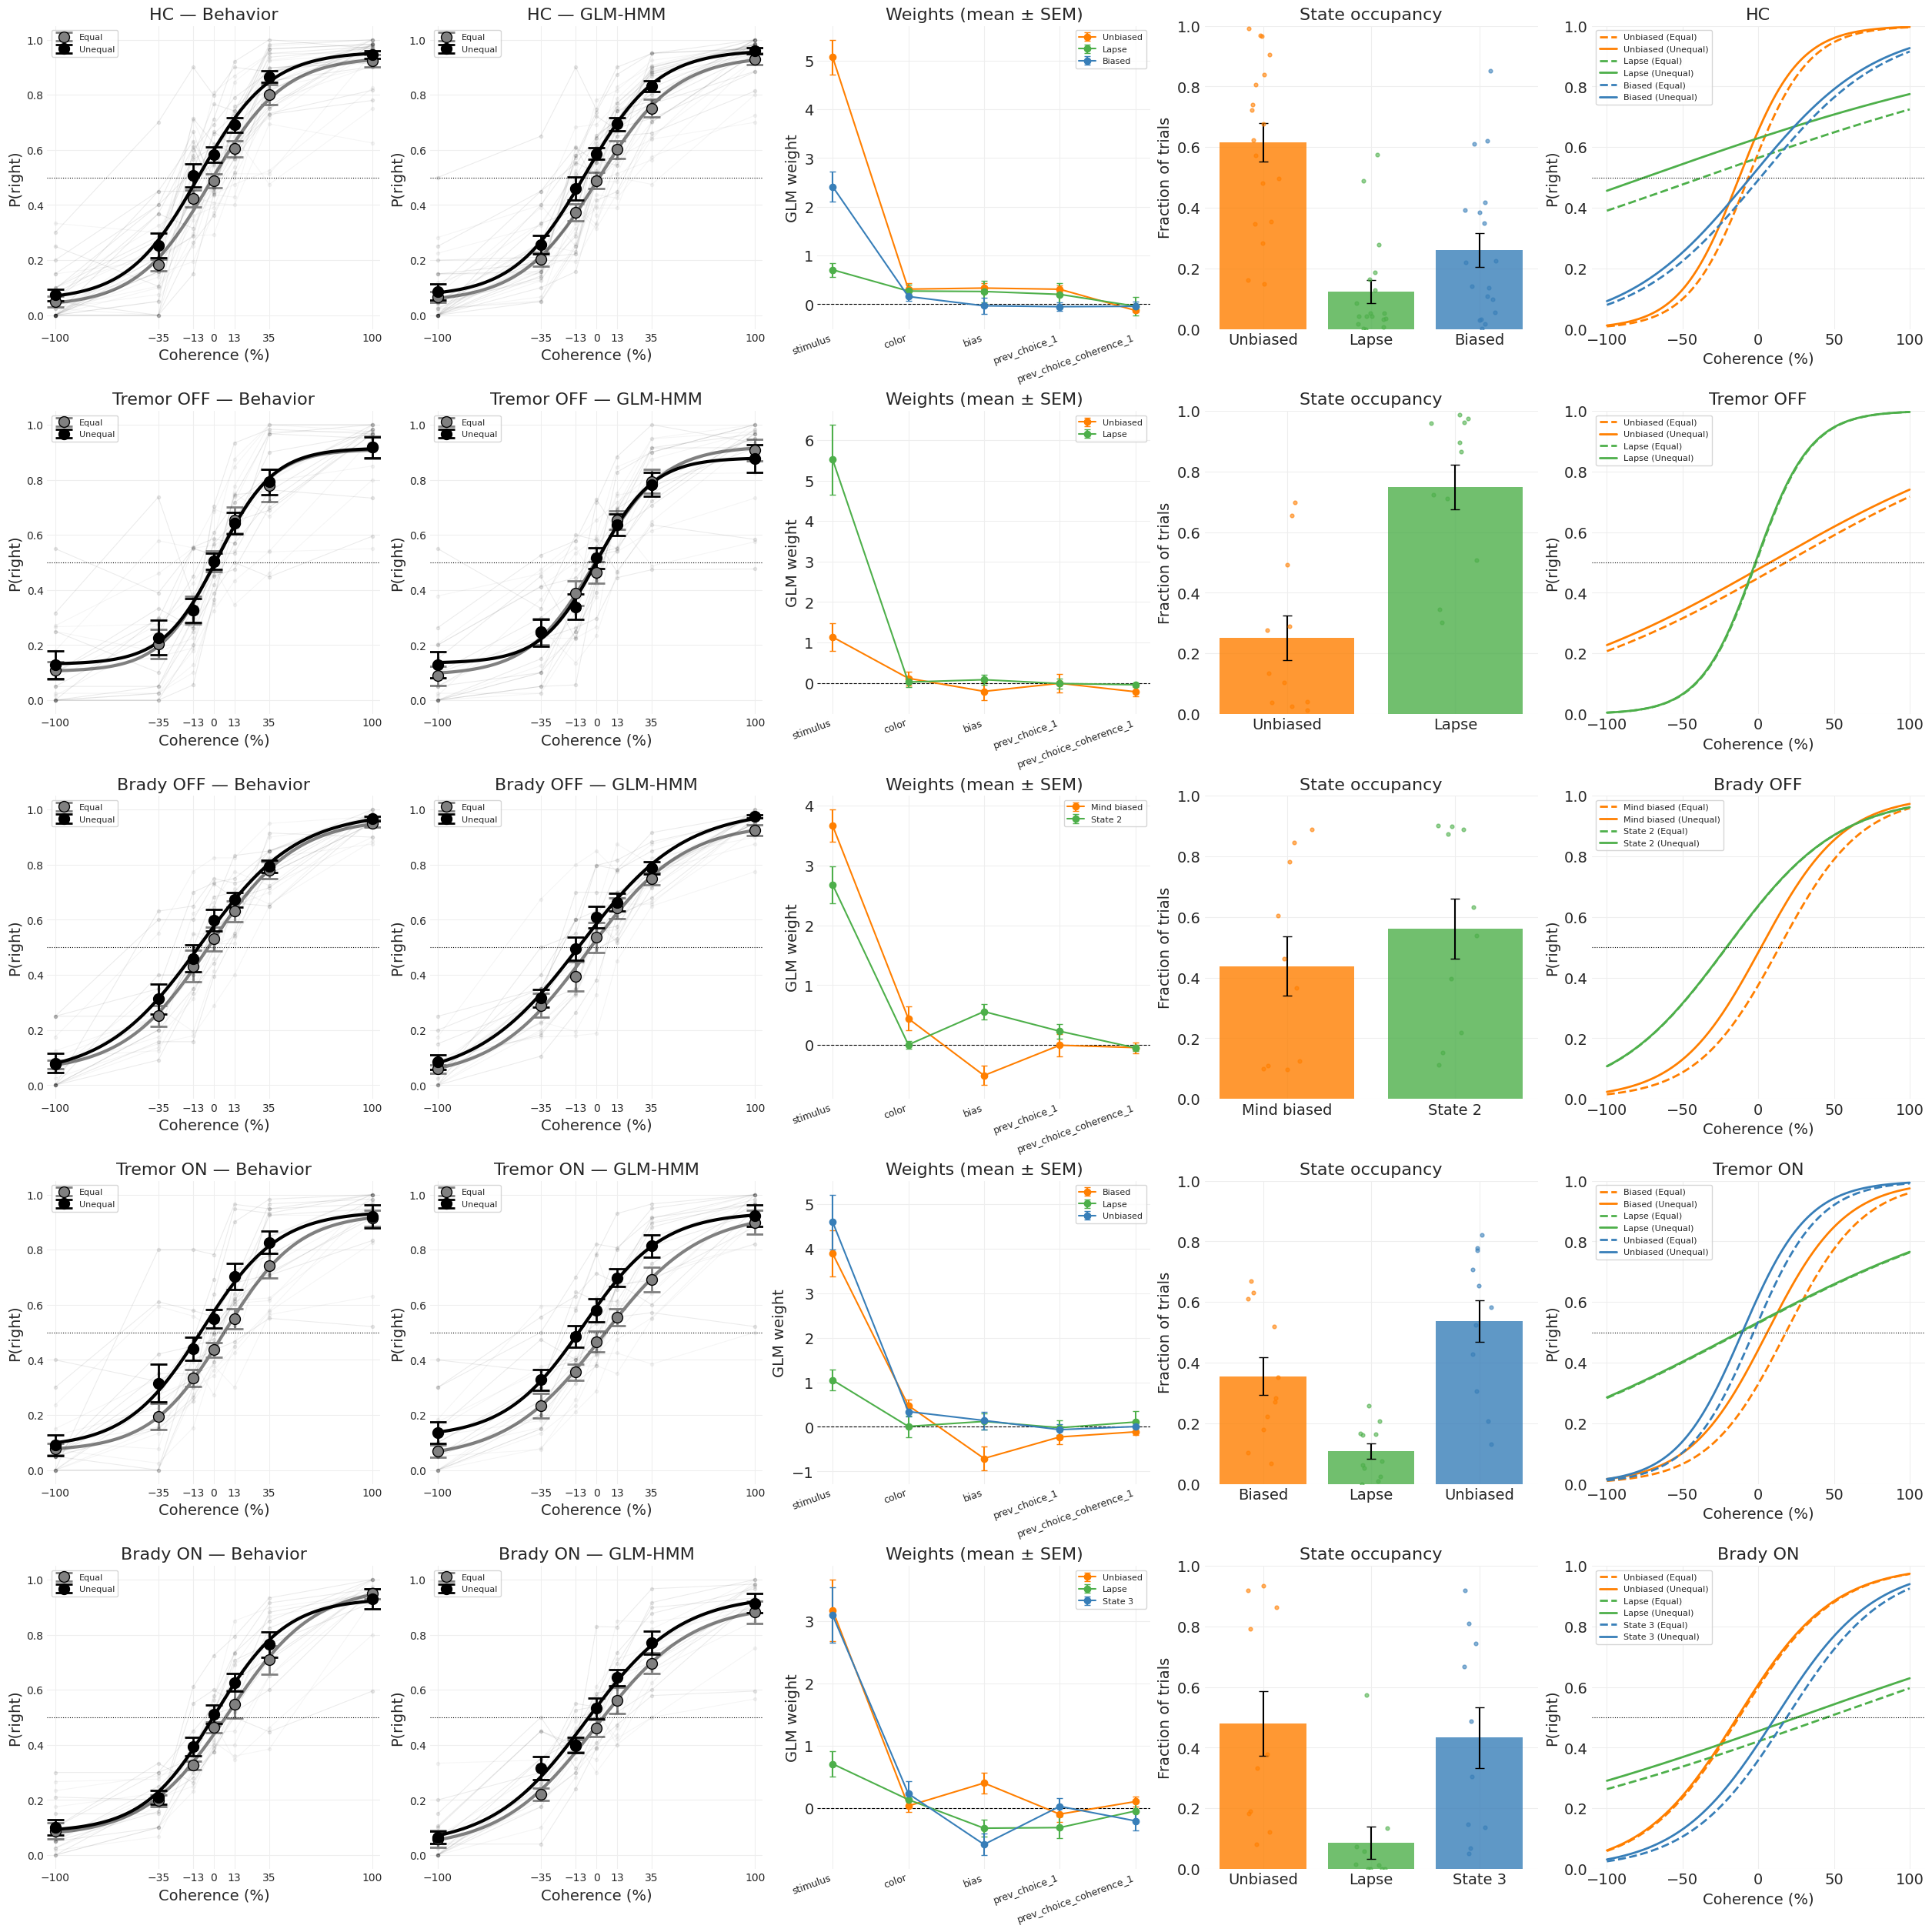

In [30]:
group_data = load_model_group_data(final_model)
n_subplots_per_group = 5
fig, axs = plt.subplots(len(group_data), 5, figsize=(5 * len(group_data), 5 * n_subplots_per_group))
for idx, (grp_name, gdata) in enumerate(group_data.items()):
    plot_group_data(grp_name, gdata, axs[idx])
